In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## Load model data and meta files

In [2]:
room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/eval/manifest_room.pdpkl')
# for tuple_ in room_manifest.itertuples():
#     print(tuple_)
#     break
room_material_map = {}
for row in room_manifest.itertuples():
    wall1 = row.material_x0[0].split(',')[0]
    wall2 = row.material_y1[0].split(',')[0]
    if wall1 == wall2:
        wall_str = f"{wall1} walls"
    else:
        wall_str = f"{wall1} and {wall2} walls"

    floor = row.material_z0[0].split(',')[0]
    ceiling = row.material_z1[0].split(',')[0]
    name_str = f"{wall_str} \n {floor} floor \n {ceiling} ceiling"

    if row.index_room in [5, 6]:
        name_str = 'Alternate speaker room'
    if row.index_room in [6, 8]:
        name_str += ' \n head rotated'
    else:
        head_rotated = ''
    if 'Anechoic' in name_str:
        name_str = "Anechoic"
    room_material_map[row.index_room] = name_str
# room_material_map = {row.index_room: f"{row.material_x0[0].split(',')[0]} and \n {row.material_y1[0].split(',')[0]} walls \n {row.material_z0[0].split(',')[0]} floor \n {row.material_z1[0].split(',')[0]} ceiling" for row in room_manifest.itertuples()}
# room_material_map[5] = 'standard speaker room'
room_material_map

{0: 'Anechoic',
 1: 'Wood panelling on glass fiber blanket walls \n Carpet on foam rubber padding floor \n Highly absorptive panels ceiling',
 2: 'Brick walls \n Wood parquet on concrete floor \n Plaster ceiling',
 3: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 4: 'Concrete walls \n Linoleum floor \n Acoustic tiles ceiling',
 5: 'Alternate speaker room',
 6: 'Alternate speaker room \n head rotated',
 7: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 8: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling \n head rotated'}

In [3]:
import pickle 

# manifest_path = "binaural_test_manifests/sim_2024_human_experiment.pkl"
manifest_path = "binaural_test_manifests/symmetric_distractor_conditions_w_front_back_neg_21_to_6_dBSNR_min_reverb_mit_room.pkl"
with open(manifest_path, "rb") as f: 
    manifest = pickle.load(f)
    

In [4]:
manifest_df  = pd.DataFrame(manifest.values())
manifest_df

,target_loc,distract_loc,snr,symmetric_distractor,test_room_meta
0,"(0, -20)","[0, -20]",6.0,True,{'room_manifest': '/om2/user/imgriff/spatial_a...
1,"(0, -20)","[0, -20]",3.0,True,{'room_manifest': '/om2/user/imgriff/spatial_a...
2,"(0, -20)","[0, -20]",0.0,True,{'room_manifest': '/om2/user/imgriff/spatial_a...
3,"(0, -20)","[0, -20]",-3.0,True,{'room_manifest': '/om2/user/imgriff/spatial_a...
4,"(0, -20)","[0, -20]",-6.0,True,{'room_manifest': '/om2/user/imgriff/spatial_a...
...,...,...,...,...,...
415,"(0, 40)","[0, 0]",-9.0,False,{'room_manifest': '/om2/user/imgriff/spatial_a...
416,"(0, 40)","[0, 0]",-12.0,False,{'room_manifest': '/om2/user/imgriff/spatial_a...
417,"(0, 40)","[0, 0]",-15.0,False,{'room_manifest': '/om2/user/imgriff/spatial_a...
418,"(0, 40)","[0, 0]",-18.0,False,{'room_manifest': '/om2/user/imgriff/spatial_a...


In [5]:
# spkr_room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/mit_bldg46room1004/manifest_room.pdpkl')
spkr_room_manifest = pd.read_pickle('/om2/user/imgriff/spatial_audio_pipeline/assets/brir/mit_bldg46room1004_min_reverb/manifest_room.pdpkl')

In [6]:

spkr_room_manifest

,head_azim,head_pos_xyz,index_room,is_outdoor,material_x0,material_x1,material_y0,material_y1,material_z0,material_z1,room_dim_xyz,room_materials
0,0,"[2.3, 3.6, 0.9]",0,False,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,carpet on foam rubber padding,"highly absorptive panels, 1in, 16in below ceiling","[4.66, 5.9, 2.48]","[11, 11, 11, 11, 15, 20]"
1,0,"[3.6, 2.36, 0.9]",1,False,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,carpet on foam rubber padding,"highly absorptive panels, 1in, 16in below ceiling","[5.9, 4.66, 2.48]","[11, 11, 11, 11, 15, 20]"
2,0,"[2.36, 2.3, 0.9]",2,False,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,carpet on foam rubber padding,"highly absorptive panels, 1in, 16in below ceiling","[4.66, 5.9, 2.48]","[11, 11, 11, 11, 15, 20]"
3,0,"[2.3, 2.3, 0.9]",3,False,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,carpet on foam rubber padding,"highly absorptive panels, 1in, 16in below ceiling","[5.9, 4.66, 2.48]","[11, 11, 11, 11, 15, 20]"


In [7]:
# Path to results 

output_paths = list(Path(f"binaural_eval/texture_srm_experiment/").glob("*/*.pkl"))

# stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/speech_in_synthetic_textures/separated_sources/manifest.pdpkl')
texture_manifest  = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/human_experiment_v00/synthetic_textures/manifest.pdpkl')
texture_ix_map = {item.index_texture:item.label for item in texture_manifest[['index_texture', 'label']].drop_duplicates().itertuples()}
# remove '_yout' from labels 
texture_ix_map = {k:re.sub('_yout$', '', v) for k,v in texture_ix_map.items()}

word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v:k for k,v in word_class_map.items()}
# stim_manifest_df['target_word'] = stim_manifest_df['label_word_int'].map(ix_to_word)

remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

results_dfs = []

gend_map = {True:'same', False:'different'}

for path in output_paths:
    if 'v09' not in str(path):
        continue
    # if not any(name in str(path) for name in ['word_task_half_co_loc_v08_gender_bal_4M_sanity']):# 'word_task_half_co_loc_v08']):
    #     continue
    if 'modulated' in path.stem:
        continue 
    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    # break
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df['model'] = path.parent.stem

    # if not 'min' in path.stem: 
    #     df = df.join(anech_stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')
    #     df.rename(columns={'bg_word':"distractor_word"}, inplace=True)  
    #     df['sex_cond'] = df["gender"].values == df['bg_gender'].values
    #     df['sex_cond'] =  df['sex_cond'].map(gend_map)
    # else:
    # # # merge with stim manifest
    # df.loc[df.index.values, ['word', 'distractor_word','sex_cond']] = stim_manifest_df.loc[df.stim_ix_list.values, ['word', 'distractor_word','sex_cond']].values
    df['target_word'] = df['true_word_int'].map(ix_to_word)
    df['pred_word'] = df['preds'].map(ix_to_word)
    df['correct'] = (df['true_word_int'] == df['preds']).astype('int')
    # df['str_confusions'] = df[['pred_word', 'distractor_word']].apply(lambda x: 1 if x.pred_word in x.distractor_word else 0, axis=1)
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
    df['snr'] = snr 
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
    # # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)
    df['distractor_elev'] = df['distractor_elev'].astype(int)
    df['room_ix'] = int(re.search('room(-?\d+)', path.stem).group(0).strip('room'))
    df['room_type'] = re.search('distractor_(.*?)_room', path.stem).group(0).split('distractor_')[-1].split("_room")[0]
    df['n_distractors'] = 1 if '1_distractor' in path.stem else 2
    df['test_set'] = 'all_stim' if 'all_stim' in path.stem else 'subset'
    df['texture_str'] = df['textures'].map(texture_ix_map)
    results_dfs.append(df)

results = pd.concat(results_dfs)

In [8]:
results.loc[results.room_type == 'eval', 'room_str'] = results.loc[results.room_type == 'eval', 'room_ix'].map(room_material_map)

results.loc[results.room_type == 'mitb46', 'room_str'] = 'Normal speaker array'
results.loc[results.room_type == 'mitb46', 'room_ix'] = 9 # use n from diff room notebook

results.loc[results.room_type.str.contains('reverb'), 'room_str'] = 'Min. reverb speaker array'
results.loc[results.room_type.str.contains('reverb'), 'room_ix'] = 10 # use n from diff room notebook

In [9]:
# results[(results.target_azim == results.distractor_azim) & (results.target_elev != results.distractor_elev)]

In [10]:
grouped_model_results = results.groupby(['model', 'target_azim', 'target_elev', 'distractor_azim', 'texture_str',
                                   'distractor_elev','snr', 'room_str']).agg({'accuracy':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_model_results.columns = ['_'.join(col).strip() for col in grouped_model_results.columns.values]
# remove trailing underscore
grouped_model_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_model_results.columns.values]



In [57]:
grouped_model_results['model_name'] = grouped_model_results['model'].map(util_analysis.model_name_dict)

In [58]:
grouped_model_results.model_name.unique()

array(['Early-only', 'Feature-gain model v09', 'Late-only',
       'Baseline CNN v09'], dtype=object)

In [15]:
grouped_model_results.target_elev.unique()

array([-20,   0,  40])

In [21]:
(grouped_model_results.distractor_elev == grouped_model_results.target_elev).sum() / len(grouped_model_results)

0.9100609756097561

In [22]:
grouped_model_results[grouped_model_results.distractor_elev != grouped_model_results.target_elev]

,model,target_azim,target_elev,distractor_azim,texture_str,distractor_elev,snr,room_str,accuracy_mean,accuracy_sem
9308,word_task_early_only_v09,0,-20,0,16mm_projector,0,-21,Min. reverb speaker array,0.016502,0.007331
9309,word_task_early_only_v09,0,-20,0,16mm_projector,0,-18,Anechoic,0.026403,0.009226
9310,word_task_early_only_v09,0,-20,0,16mm_projector,0,-18,Min. reverb speaker array,0.039604,0.011223
9311,word_task_early_only_v09,0,-20,0,16mm_projector,0,-15,Min. reverb speaker array,0.085809,0.016117
9312,word_task_early_only_v09,0,-20,0,16mm_projector,0,-12,Anechoic,0.227723,0.024132
...,...,...,...,...,...,...,...,...,...,...
84614,word_task_v09_control_no_attn,0,40,0,wind_through_grass,0,-6,Min. reverb speaker array,0.478548,0.028745
84615,word_task_v09_control_no_attn,0,40,0,wind_through_grass,0,3,Min. reverb speaker array,0.755776,0.024722
84616,word_task_v09_control_no_attn,0,40,0,wind_through_grass,0,6,Min. reverb speaker array,0.801980,0.022932
84617,word_task_v09_control_no_attn,0,40,0,wind_through_grass,20,-6,Anechoic,0.544554,0.028657


In [16]:
grouped_model_results.distractor_azim.unique()

array([-180, -150, -120,  -90,  -60,  -40,  -30,  -20,  -10,   -5,    0])

In [17]:
grouped_model_results.target_azim.unique()

array([0])

### Compute model thresholds for azimuth conditions 

In [24]:
# filter for same target and distractor elev
to_plot = grouped_model_results[grouped_model_results.distractor_elev == grouped_model_results.target_elev].copy()

to_plot.distractor_azim = to_plot.distractor_azim.abs()                    
azim_results_for_thresh = to_plot.groupby(['model', 'room_str', 'target_elev', 'distractor_azim', 'texture_str', 'snr']).agg({'accuracy_mean':'mean'}).reset_index()


azim_thresholds = []
# p0 = [0.0, -4, 4]
for (model, room, elev, dist_type, azim), group in azim_results_for_thresh.groupby(['model', 'room_str', 'target_elev', 'texture_str', 'distractor_azim']): #, 'gender_cond']):
    try:
        thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.accuracy_mean.values, bounds_from_data=True)#, p0=p0)
        if np.isnan(thresh):
            print(f"Threshold is nan for azim {azim}")
        azim_thresholds.append({'model': model, "room":room, "dist_type":dist_type, 'elev':elev, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
    except Exception as e:
        # print(e)
        # print(f"Error for azim {azim}, room {room}, dist_type {dist_type}")
        continue
    
azim_thresh_df = pd.DataFrame(azim_thresholds)

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/optimize/minpack.py:828: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/util_analysis.py:21: RuntimeWarning: invalid value encountered in divide
  p0 = (1, x[np.argmin(np.abs(np.cumsum(y) / np.sum(y) - 0.5))], 1)


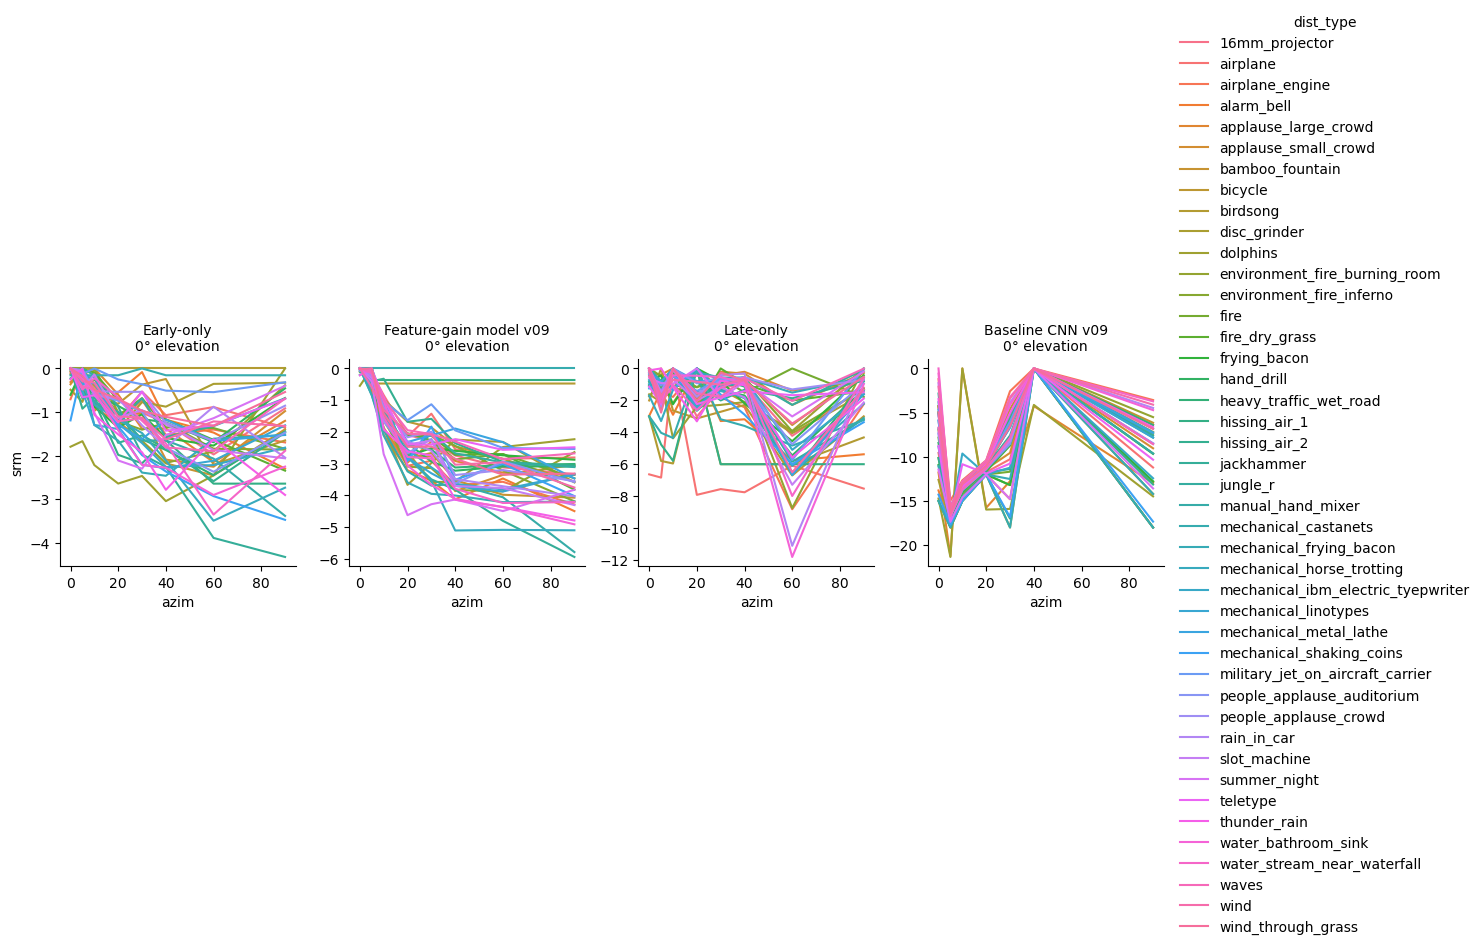

In [123]:
### Only plot 0 to 90 degrees. Someteimes the model is better at 180 than 0
# to_plot = azim_thresh_df[(azim_thresh_df.room == 'Min. reverb speaker array')].copy()
to_plot = azim_thresh_df[(azim_thresh_df.room == 'Anechoic') & (azim_thresh_df.azim <= 90) & (azim_thresh_df.elev == 0)].copy()

to_plot['model_name'] = to_plot.model.map(util_analysis.model_name_dict)
for model in to_plot.model.unique():
    for room_type in to_plot.room.unique():
        for elev in to_plot.elev.unique():
            for dist_type in to_plot.dist_type.unique():
                ixs = (to_plot.model == model) & (to_plot.dist_type == dist_type) & (to_plot.room == room_type) & (to_plot.elev == elev)
                model_data = to_plot[ixs]
                to_plot.loc[ixs, 'srm'] = model_data.threshold - model_data.threshold.max()

g = sns.relplot(data=to_plot, x='azim', y='srm', hue='dist_type', col='model_name', row='elev', kind='line',
                errorbar=('se', 2),
                err_style='bars',
                height=3, aspect=1, 
                 facet_kws={"sharey":False, "sharex":False})
g.set_titles("{col_name}\n{row_name}° elevation")

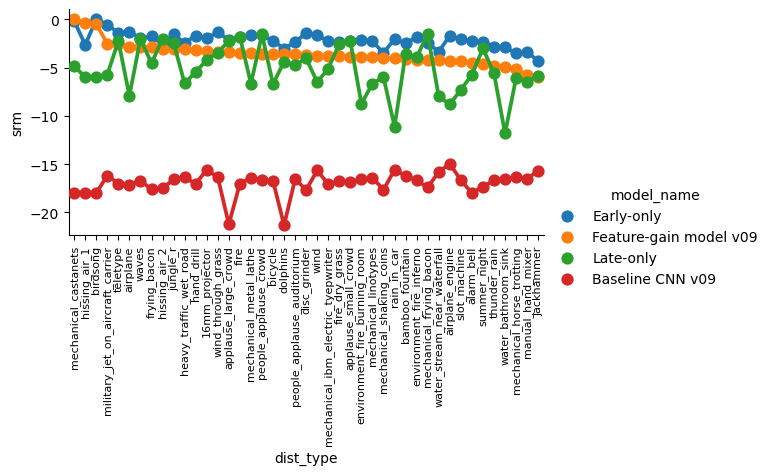

In [129]:
# for each model, distractor type, room, and elevation, find the azimuth with the minimum srm value 
min_azim_ixs = to_plot.groupby(['model', 'dist_type', 'room', 'elev']).srm.idxmin()
min_azim_ixs = min_azim_ixs.dropna()
min_azim_ixs = min_azim_ixs.astype(int)
min_azim_ixs = to_plot.loc[min_azim_ixs]

# compute metric for srm   
min_azim_ixs['dB_per_degree'] = min_azim_ixs.srm / min_azim_ixs.azim
min_azim_ixs['degree_per_dB'] = min_azim_ixs.azim / min_azim_ixs.srm

# mean is just over 1 number here 
texture_order = min_azim_ixs[min_azim_ixs.model_name == 'Feature-gain model v09'].groupby('dist_type')['srm'].mean().sort_values(ascending=False).index

# plot the srm by azim metric as a function of distractor type 

g = sns.catplot(data=min_azim_ixs, x='dist_type', y='srm', order=texture_order,  
                hue='model_name', kind='point',
                height=3, aspect=2, 
                 facet_kws={"sharey":False, "sharex":False})

g.set_xticklabels(rotation=90, fontsize=8)

In [96]:
min_azim_ixs

,model,room,dist_type,elev,azim,threshold,model_name,srm,srm_by_azim
1894,word_task_early_only_v09,Min. reverb speaker array,16mm_projector,0,10,-7.826443,Early-only,-1.311468,7.625042
1909,word_task_early_only_v09,Min. reverb speaker array,airplane,0,90,-13.657483,Early-only,-2.175420,41.371316
1915,word_task_early_only_v09,Min. reverb speaker array,airplane_engine,0,20,-4.856565,Early-only,-1.856565,10.772585
1929,word_task_early_only_v09,Min. reverb speaker array,alarm_bell,0,90,-17.073408,Early-only,-3.162885,28.455036
1935,word_task_early_only_v09,Min. reverb speaker array,applause_large_crowd,0,20,-10.696908,Early-only,-1.937501,10.322575
...,...,...,...,...,...,...,...,...,...
11316,word_task_v09_control_no_attn,Min. reverb speaker array,water_bathroom_sink,0,30,-21.000000,Baseline CNN v09,-18.000000,1.666667
11324,word_task_v09_control_no_attn,Min. reverb speaker array,water_stream_near_waterfall,0,30,-19.030236,Baseline CNN v09,-16.427345,1.826223
11332,word_task_v09_control_no_attn,Min. reverb speaker array,waves,0,30,-20.539872,Baseline CNN v09,-17.539872,1.710389
11340,word_task_v09_control_no_attn,Min. reverb speaker array,wind,0,30,-21.000000,Baseline CNN v09,-18.000000,1.666667


Index(['16mm_projector', 'wind', 'military_jet_on_aircraft_carrier', 'bicycle',
       'rain_in_car', 'environment_fire_inferno', 'mechanical_metal_lathe',
       'applause_large_crowd', 'hissing_air_1', 'hissing_air_2',
       'fire_dry_grass', 'airplane', 'mechanical_shaking_coins', 'jungle_r',
       'jackhammer', 'people_applause_auditorium', 'alarm_bell', 'teletype',
       'fire', 'mechanical_ibm_electric_tyepwriter', 'slot_machine',
       'thunder_rain', 'environment_fire_burning_room',
       'mechanical_frying_bacon', 'applause_small_crowd', 'dolphins',
       'manual_hand_mixer', 'water_bathroom_sink', 'bamboo_fountain',
       'summer_night', 'people_applause_crowd', 'hand_drill',
       'water_stream_near_waterfall', 'heavy_traffic_wet_road', 'waves',
       'airplane_engine', 'mechanical_linotypes', 'mechanical_horse_trotting',
       'disc_grinder', 'birdsong', 'mechanical_castanets',
       'wind_through_grass', 'frying_bacon'],
      dtype='object', name='dist_type')

In [51]:
test_manifest_df['test_room'].unique()

array(['/om2/user/imgriff/spatial_audio_pipeline/assets/brir/mit_bldg46room1004_min_reverb/manifest_brir.pdpkl',
       '/om2/user/msaddler/spatial_audio_pipeline/assets/brir/eval/manifest_brir.pdpkl',
       '/om2/user/msaddler/spatial_audio_pipeline/assets/brir/mit_bldg46room1004/manifest_brir.pdpkl'],
      dtype=object)

In [55]:
test_manifest_df[test_manifest_df['test_room'].str.contains('eval')].index.max()

839

In [52]:
np.diff(test_manifest_df[test_manifest_df['test_room'].str.contains('eval')].index.values).sum()

419

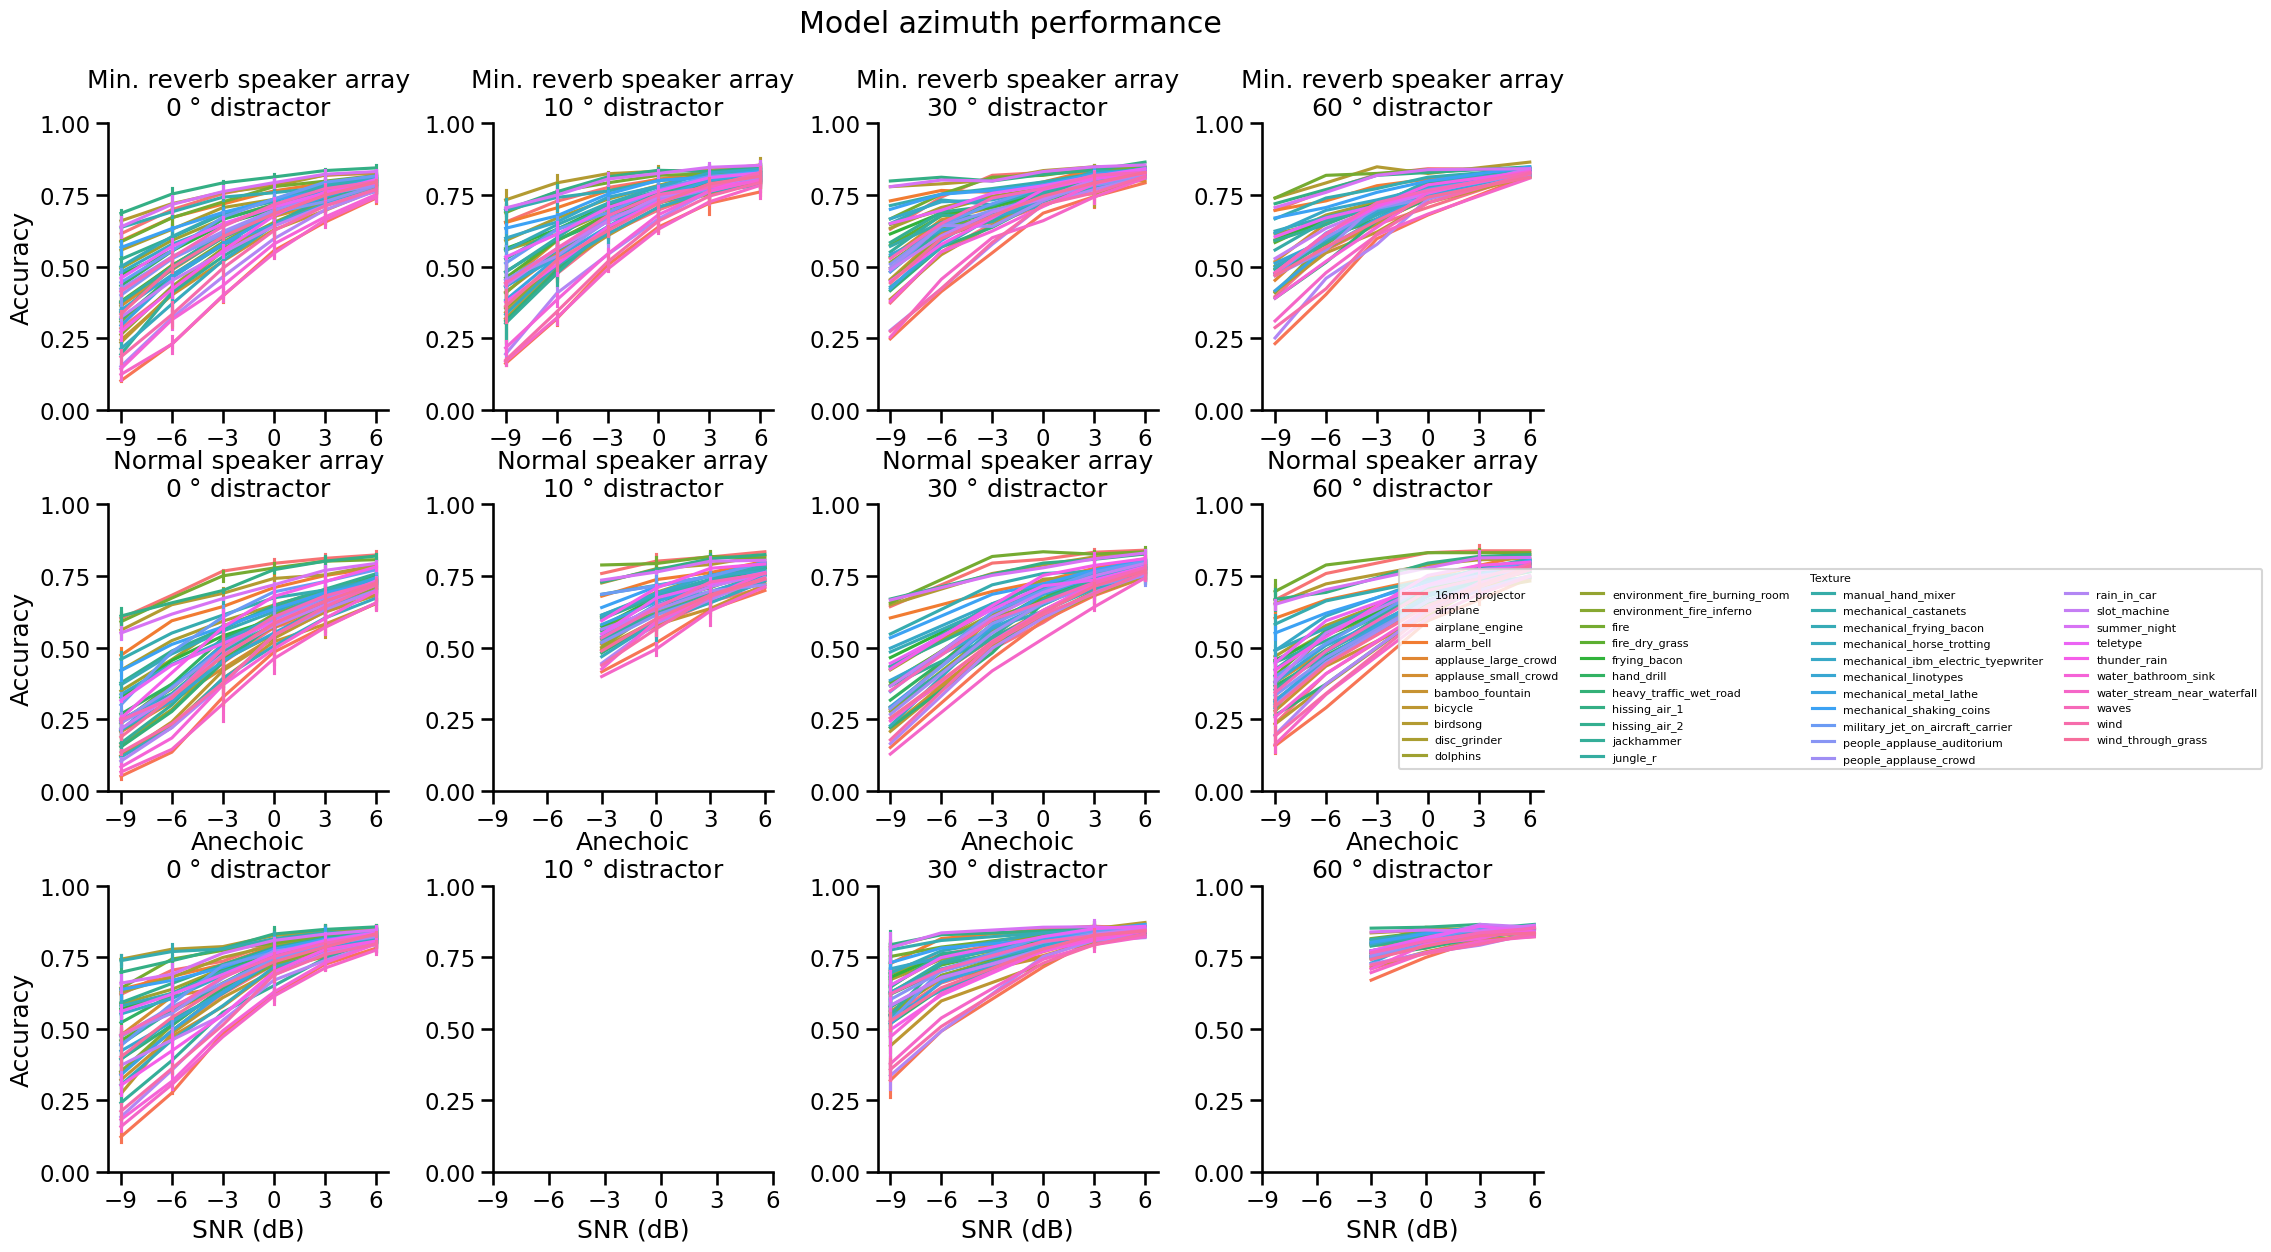

In [80]:
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                x='snr', y='accuracy_mean', col="distractor_azim",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                hue='texture_str', 
                row='room_str',
                # palette=palette, 
                errorbar=('se', 2),
                err_style='bars',
                height=4, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
# new_title = 'Distractor\nazimuth\n($\degree$, +/-)'
# g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{row_name}\n{col_name}$\degree$ distractor")
plt.suptitle(f'Model azimuth performance', y=1.05)
# make legend have columns 
g._legend.remove()
g.fig.legend( title='Texture', loc='center right', fontsize=8, title_fontsize=8, ncol=4, bbox_to_anchor=(1.1, 0.5))


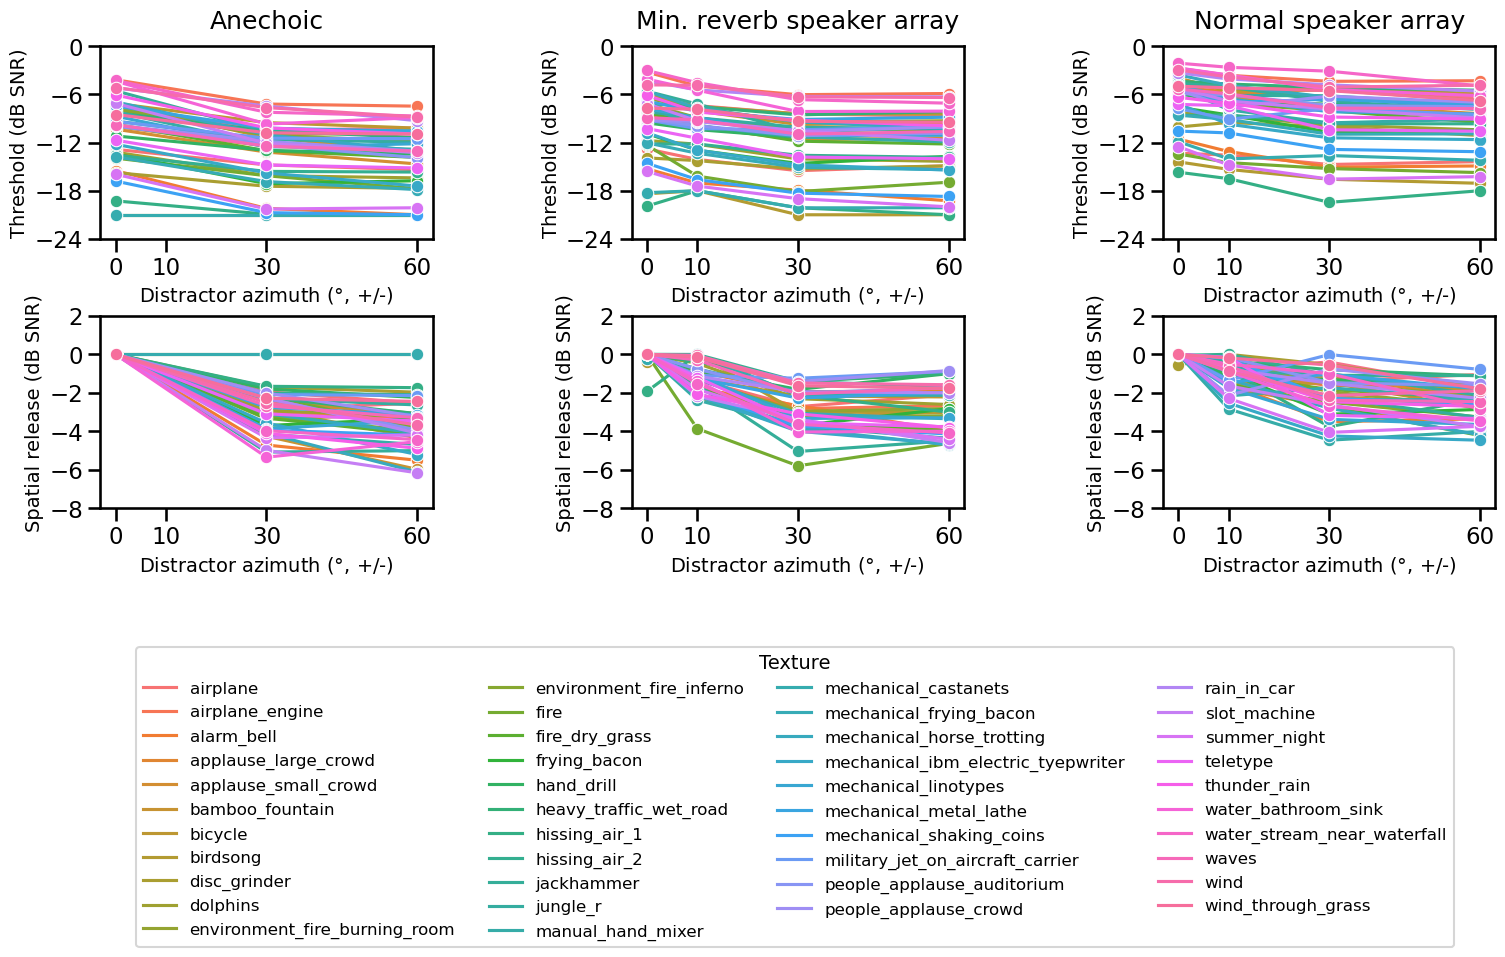

In [66]:


## First, get grand average. Then bootstrap for error 
sns.set_context('talk')


# plt.figure()
# g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
#                 x='snr', y='accuracy_mean', col="distractor_azim",
#                 kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
#                 hue='texture_str', 
#                 row='room_str',
#                 # palette=palette, 
#                 errorbar=('se', 2),
#                 err_style='bars',
#                 height=4, aspect=1)
# g.set_axis_labels("SNR (dB)", "Accuracy")
# # set legend title 
# # new_title = 'Distractor\nazimuth\n($\degree$, +/-)'
# # g._legend.set_title(new_title)
# # set xticks from -9 to 6
# g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# # column titles 
# g.set_titles("{row_name}\n{col_name}")
# plt.suptitle(f'Model azimuth performance', y=1.05)
# # make legend have columns 
# g._legend.remove()
# g.fig.legend( title='Texture', loc='center right', fontsize=8, title_fontsize=8, ncol=4, bbox_to_anchor=(1.1, 0.5))

fontsize=14
# get srm per model
for model in azim_thresh_df.model.unique():
    for dist_type in azim_thresh_df.dist_type.unique():
        for room_type in azim_thresh_df.room.unique():
            ixs = (azim_thresh_df.model == model) & (azim_thresh_df.dist_type == dist_type) & (azim_thresh_df.room == room_type)
            model_data = azim_thresh_df[ixs]
            azim_thresh_df.loc[ixs, 'srm'] = model_data.threshold - model_data.threshold.max()
# plot azim thresholds

# sns.set_style('white')
fig, axs = plt.subplots(2,3, figsize=(18, 6))
for ix, room in enumerate(azim_thresh_df.room.unique()):
    data = azim_thresh_df[azim_thresh_df.room == room]
    sns.lineplot(data=data, x='azim', y='threshold', hue='dist_type', marker='o', ax=axs[0,ix],  legend=False)
    axs[0,ix].set_title(f'{room}', y=1.05)
# axs[0].set_title(f'Model azimuth thresholds', y=1.05)
# axs[0].set_title(f'Model azimuth thresholds', y=1.05)

    axs[0, ix].set_xlabel('Distractor azimuth ($\degree$, +/-)', fontsize=fontsize)
    axs[0, ix].set_ylabel("Threshold (dB SNR)", fontsize=fontsize)
    axs[0, ix ].set_ylim(-24,0)
    axs[0, ix ].set_xticks([0, 10, 30, 60])
    axs[0, ix].set_yticks(np.arange(-24,1,6))


    # sns.set_style('white')
    sns.lineplot(data=data, x='azim', y='srm', hue='dist_type',  marker='o', ax=axs[1, ix], legend=True if ix == 1 else False )
    # axs[1].set_title(f'Model azimuth spatial release', y=1.05)
    axs[1, ix].set_xlabel('Distractor azimuth ($\degree$, +/-)', fontsize=fontsize)
    axs[1, ix].set_ylabel("Spatial release (dB SNR)", fontsize=fontsize)
    axs[1, ix].set_ylim(-8,2)
    axs[1, ix].set_xticks([0, 10, 30, 60])
    axs[1, ix].set_yticks(np.arange(-8,3,2))

# adjust w space 
plt.subplots_adjust(wspace=0.6, hspace=0.4)
# adjust legend 
handles, labels = axs[1,1].get_legend_handles_labels()
axs[1,1].legend(handles=handles[1:], labels=labels[1:], title='Texture',  loc='center right', ncol=4, fontsize=12, title_fontsize=fontsize, bbox_to_anchor=(2.5, -1.5))



In [72]:
# avg threshold estimates for 0 and 10 elevation separation 
to_plot = grouped_model_results[
                    # (grouped_model_results.n_distractors == 2)
                        #   & (grouped_model_results.room_str == 'Min. reverb speaker array')
                        	(grouped_model_results.distractor_azim == 0) 
                        #   & (grouped_model_results.snr.isin([6,3, 0, -3, -6, -9]))
                          ]

to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['distractor_elev']).abs()

elev_results_for_thresh = to_plot.groupby(['model', 'room_str', 'elev_delta', 'texture_str', 'snr']).agg({'accuracy_mean':'mean'}).reset_index()



elev_thresholds = []
# p0 = [0.0, -4, 4]
for (model, room, dist_type, elev_delta), group in elev_results_for_thresh.groupby(['model', 'room_str', 'texture_str', 'elev_delta']): #, 'gender_cond']):
    thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.accuracy_mean.values, bounds_from_data=True)#, p0=p0)
    if np.isnan(thresh):
        print(f"Threshold is nan for elev {elev_delta}")
    elev_thresholds.append({'model':model, "room":room, "dist_type":dist_type, 'elev_delta': elev_delta, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
elev_thresh_df = pd.DataFrame(elev_thresholds)


/tmp/ipykernel_712194/4137295257.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['distractor_elev']).abs()


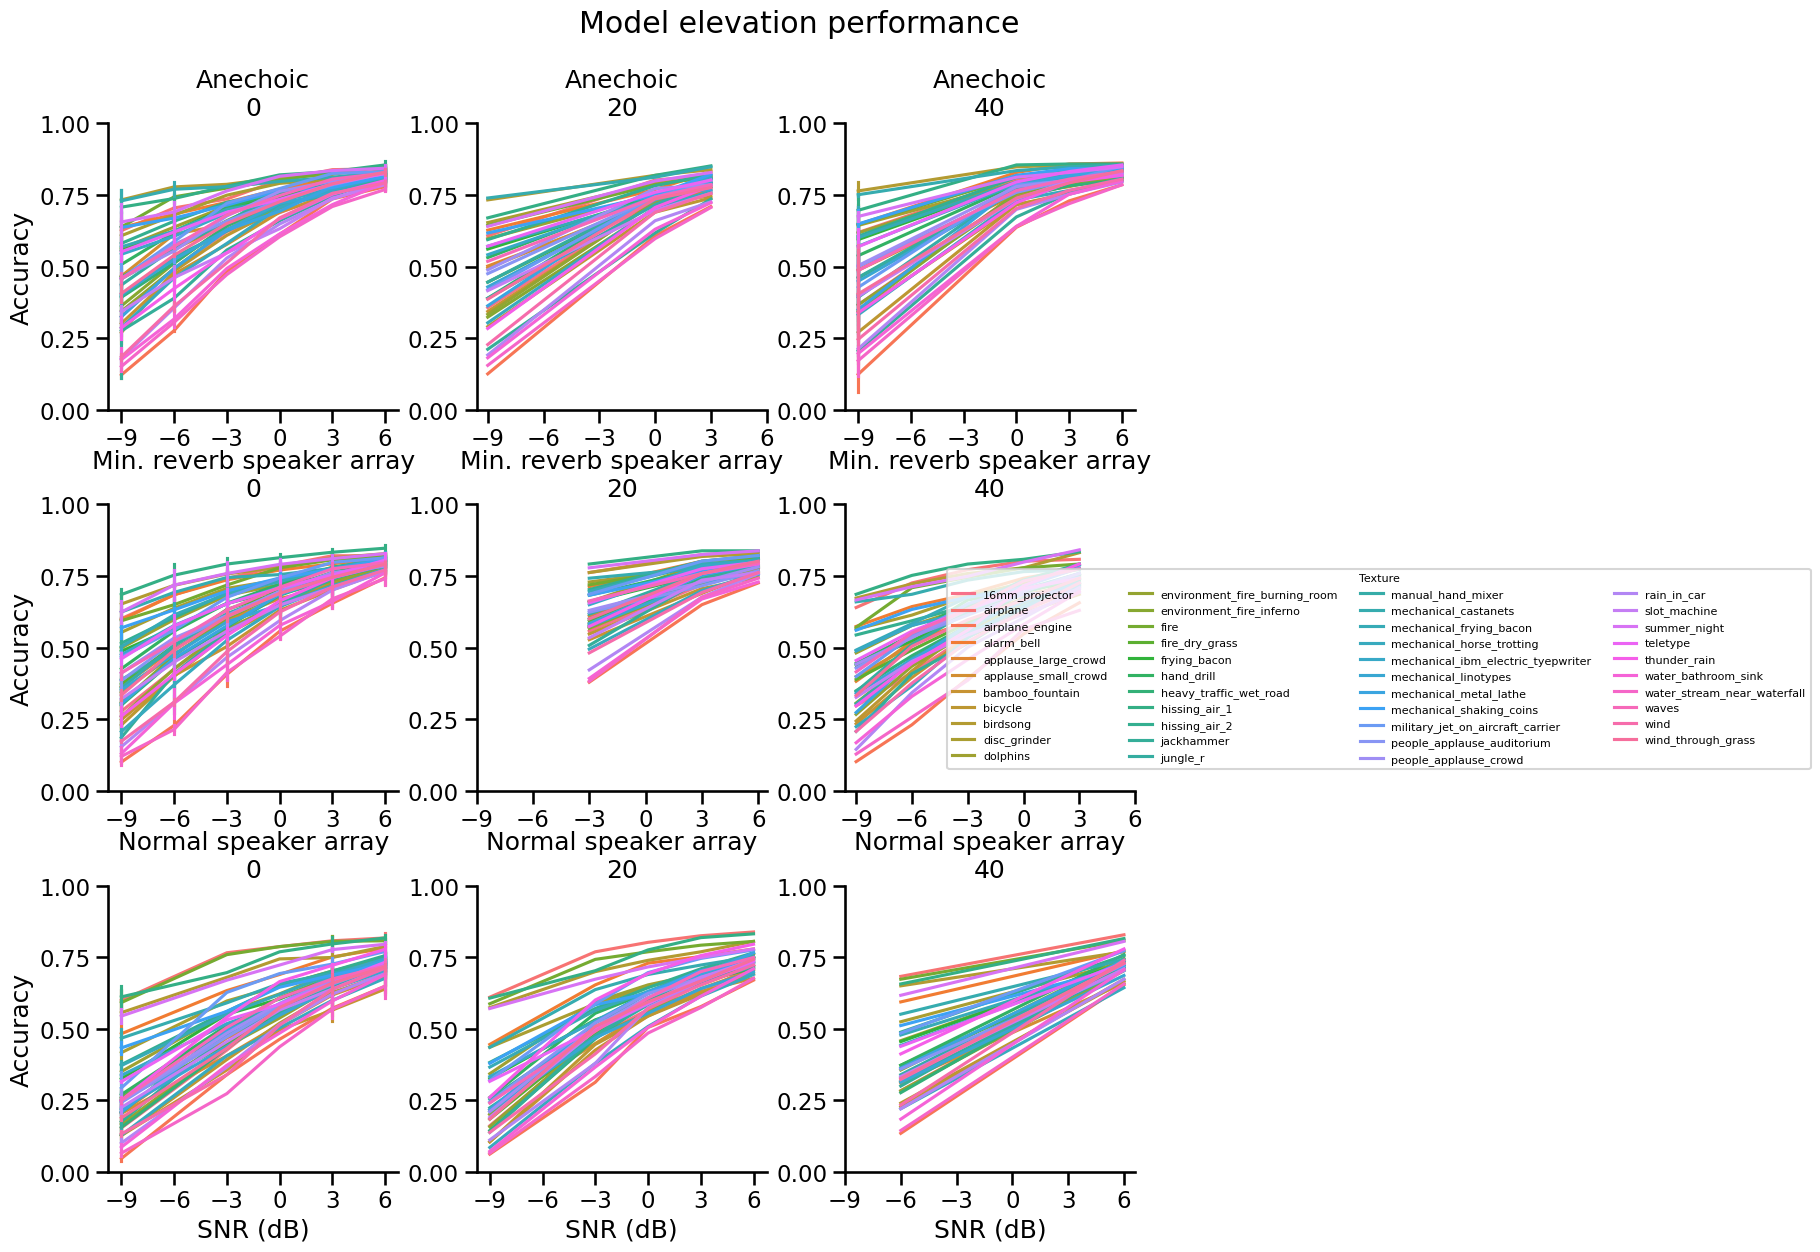

In [75]:
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                x='snr', y='accuracy_mean', col="elev_delta",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                hue='texture_str', 
                row='room_str',
                # palette=palette, 
                errorbar=('se', 2),
                err_style='bars',
                height=4, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
# new_title = 'Distractor\nazimuth\n($\degree$, +/-)'
# g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{row_name}\n{col_name}")
plt.suptitle(f'Model elevation performance', y=1.05)
# make legend have columns 
g._legend.remove()
g.fig.legend( title='Texture', loc='center right', fontsize=8, title_fontsize=8, ncol=4, bbox_to_anchor=(1.1, 0.5))

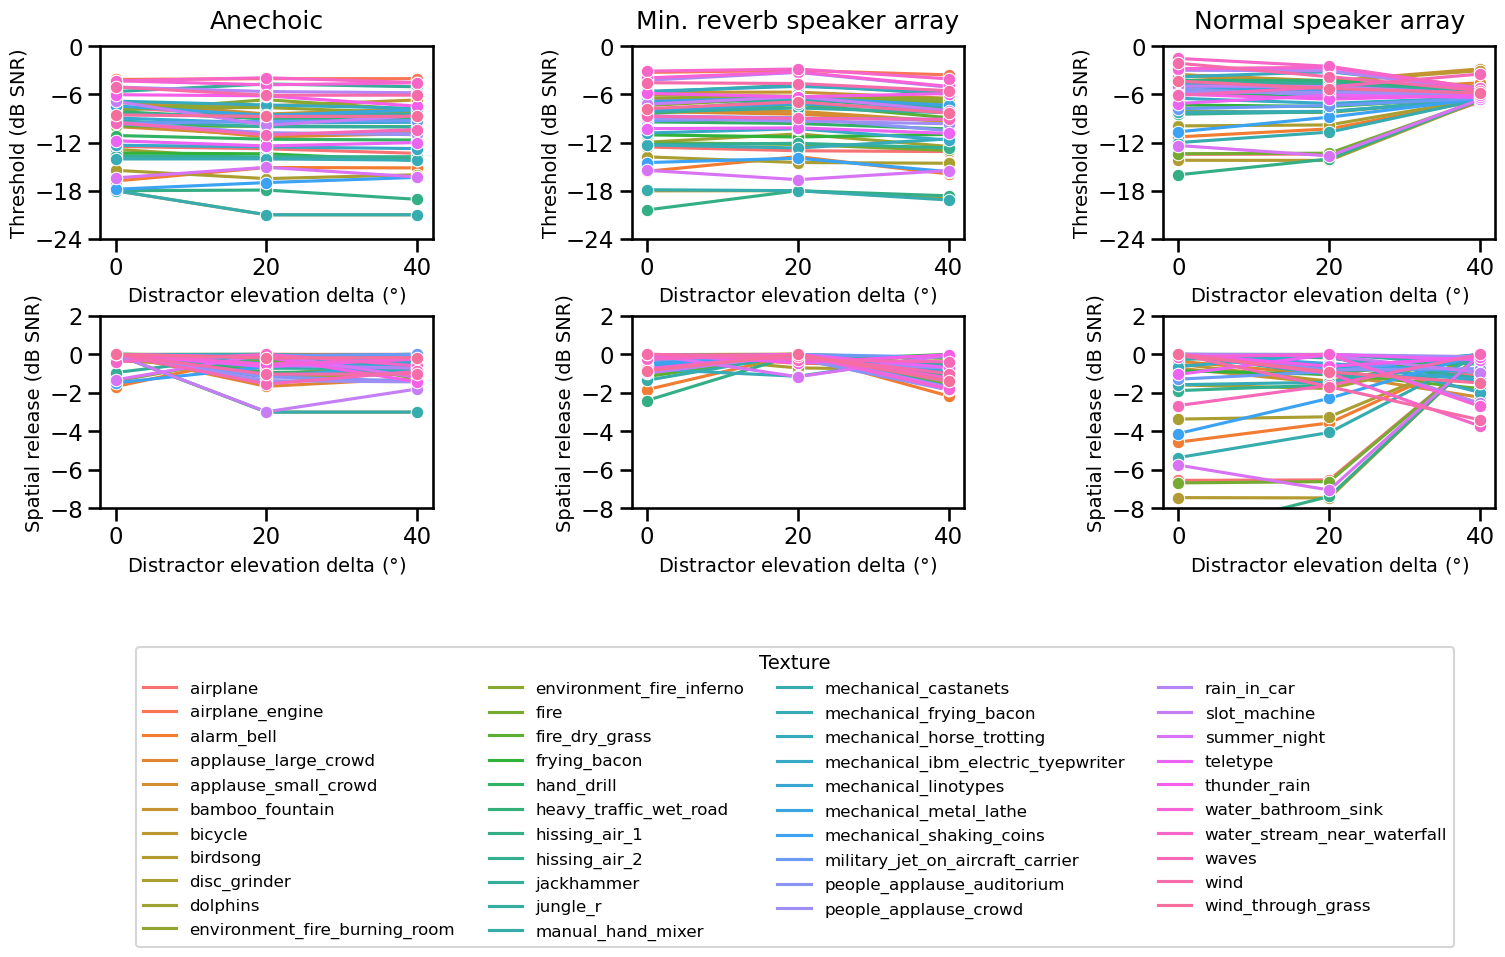

In [74]:


## First, get grand average. Then bootstrap for error 
sns.set_context('talk')


# plt.figure()
# g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
#                 x='snr', y='accuracy_mean', col="distractor_azim",
#                 kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
#                 hue='texture_str', 
#                 row='room_str',
#                 # palette=palette, 
#                 errorbar=('se', 2),
#                 err_style='bars',
#                 height=4, aspect=1)
# g.set_axis_labels("SNR (dB)", "Accuracy")
# # set legend title 
# # new_title = 'Distractor\nazimuth\n($\degree$, +/-)'
# # g._legend.set_title(new_title)
# # set xticks from -9 to 6
# g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# # column titles 
# g.set_titles("{row_name}\n{col_name}")
# plt.suptitle(f'Model azimuth performance', y=1.05)
# # make legend have columns 
# g._legend.remove()
# g.fig.legend( title='Texture', loc='center right', fontsize=8, title_fontsize=8, ncol=4, bbox_to_anchor=(1.1, 0.5))

xticks = [0, 20, 40] 
fontsize=14
# get srm per model
for model in elev_thresh_df.model.unique():
    for dist_type in elev_thresh_df.dist_type.unique():
        for room_type in elev_thresh_df.room.unique():
            ixs = (elev_thresh_df.model == model) & (elev_thresh_df.dist_type == dist_type) & (elev_thresh_df.room == room_type)
            model_data = elev_thresh_df[ixs]
            elev_thresh_df.loc[ixs, 'srm'] = model_data.threshold - model_data.threshold.max()
# plot azim thresholds

# sns.set_style('white')
fig, axs = plt.subplots(2,3, figsize=(18, 6))
for ix, room in enumerate(elev_thresh_df.room.unique()):
    data = elev_thresh_df[elev_thresh_df.room == room]
    sns.lineplot(data=data, x='elev_delta', y='threshold', hue='dist_type', marker='o', ax=axs[0,ix],  legend=False)
    axs[0,ix].set_title(f'{room}', y=1.05)
# axs[0].set_title(f'Model azimuth thresholds', y=1.05)
# axs[0].set_title(f'Model azimuth thresholds', y=1.05)

    axs[0, ix].set_xlabel('Distractor elevation delta ($\degree$)', fontsize=fontsize)
    axs[0, ix].set_ylabel("Threshold (dB SNR)", fontsize=fontsize)
    axs[0, ix ].set_ylim(-24,0)
    axs[0, ix].set_yticks(np.arange(-24,1,6))
    axs[0, ix ].set_xticks(xticks)


    # sns.set_style('white')
    sns.lineplot(data=data, x='elev_delta', y='srm', hue='dist_type',  marker='o', ax=axs[1, ix], legend=True if ix == 1 else False )
    # axs[1].set_title(f'Model azimuth spatial release', y=1.05)
    axs[1, ix].set_xlabel('Distractor elevation delta ($\degree$)', fontsize=fontsize)
    axs[1, ix].set_ylabel("Spatial release (dB SNR)", fontsize=fontsize)
    axs[1, ix].set_ylim(-8,2)
    axs[1, ix].set_yticks(np.arange(-8,3,2))
    axs[1, ix].set_xticks(xticks)


# adjust w space 
plt.subplots_adjust(wspace=0.6, hspace=0.4)
# adjust legend 
handles, labels = axs[1,1].get_legend_handles_labels()
axs[1,1].legend(handles=handles[1:], labels=labels[1:], title='Texture',  loc='center right', ncol=4, fontsize=12, title_fontsize=fontsize, bbox_to_anchor=(2.5, -1.5))

